# Lecture 1 Practical — Root Finding for Non-linear Algebraic Equations

This notebook accompanies Lecture 1 of **Modelling and Simulation**.

The main objective is to practice numerical methods for solving equations of the form

\[
f(x)=0
\]

and systems of equations of the form

\[
F(\mathbf{x})=\mathbf{0}.
\]

The practical includes:

1. Plotting and bracketing roots.
2. Bisection method.
3. Linear interpolation / false-position method.
4. Fixed-point iteration.
5. Newton's method for one equation.
6. Newton's method for systems of equations.
7. **Extension 1:** multiple roots and modified Newton's method.
8. **Extension 2:** Newton fractal for \(z^3-1=0\).

## Important note for students

Many code cells contain `TODO` sections. Some possible solution lines are present but commented out. Your task is to complete the missing parts.

All functions used in the examples are defined in the first code section, so you can easily experiment with new functions by modifying or adding entries there.

## 0. Imports and global settings

**Objective.** Import the Python libraries needed in this notebook.

We use:

- `numpy` for numerical arrays and mathematical functions.
- `matplotlib` for plotting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots reasonably large and readable.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

# Numerical tolerance used in several exercises.
DEFAULT_TOL = 1e-10
DEFAULT_MAX_ITER = 100

## 1. Define the functions used in the notebook

**Objective.** Define all example functions in one place.

This makes it easy to experiment with new equations. To try a new scalar equation, add a new entry to the `scalar_problems` dictionary with:

- `f`: the function \(f(x)\),
- `df`: its derivative \(f'(x)\), if known,
- `bracket`: a suggested interval \([a,b]\) where the root is bracketed,
- `x0`: a suggested starting point for Newton's method.

The main scalar example from the lecture is

$$
f(x)=2\sin(x)-e^{-x}-x^2.
$$

In [2]:

# ============================================================
# Scalar root-finding problems: f(x) = 0
# ============================================================

def f_lecture(x):
    """Lecture example: f(x) = 2 sin(x) - exp(-x) - x^2."""
    return 2*np.sin(x) - np.exp(-x) - x**2

def df_lecture(x):
    """Derivative of f_lecture."""
    return 2*np.cos(x) + np.exp(-x) - 2*x


def f_multiple_root(x):
    """Multiple-root example: f(x) = x^4 - 4x^2 + 4 = (x^2 - 2)^2."""
    return x**4 - 4*x**2 + 4

def df_multiple_root(x):
    """Derivative of f_multiple_root."""
    return 4*x**3 - 8*x

def ddf_multiple_root(x):
    """Second derivative of f_multiple_root."""
    return 12*x**2 - 8


# You can add your own functions here.
# Example:
#
# def f_my_problem(x):
#     return np.cos(x) - x
#
# def df_my_problem(x):
#     return -np.sin(x) - 1


scalar_problems = {
    "lecture": {
        "f": f_lecture,
        "df": df_lecture,
        "bracket": (0.0, 1.0),
        "x0": 0.5,
        "plot_interval": (-2.0, 3.0),
        "description": r"$f(x)=2\sin(x)-e^{-x}-x^2$",
    },
    "multiple_root": {
        "f": f_multiple_root,
        "df": df_multiple_root,
        "ddf": ddf_multiple_root,
        "bracket": (1.0, 2.0),
        "x0": 1.8,
        "plot_interval": (0.0, 2.5),
        "description": r"$f(x)=x^4-4x^2+4=(x^2-2)^2$",
    },
    # "my_problem": {
    #     "f": f_my_problem,
    #     "df": df_my_problem,
    #     "bracket": (0.0, 1.0),
    #     "x0": 0.5,
    #     "plot_interval": (-1.0, 2.0),
    #     "description": r"$f(x)=\cos(x)-x$",
    # },
}

# Select the scalar problem used in the next sections.
active_problem_name = "lecture"
problem = scalar_problems[active_problem_name]

f = problem["f"]
df = problem["df"]
a, b = problem["bracket"]
x0 = problem["x0"]

print("Active problem:", active_problem_name)
print("Function:", problem["description"])
print("Suggested bracket:", (a, b))
print("Suggested Newton starting point:", x0)

Active problem: lecture
Function: $f(x)=2\sin(x)-e^{-x}-x^2$
Suggested bracket: (0.0, 1.0)
Suggested Newton starting point: 0.5


## 2. Plot the function and visually locate roots

**Objective.** Before applying a root-finding method, inspect the function graphically.

Tasks:

1. Plot \(f(x)\) over the suggested interval.
2. Add a horizontal line at \(y=0\).
3. Identify intervals where the function changes sign.

f(a) = -1.0
f(b) = 0.3150625284443507


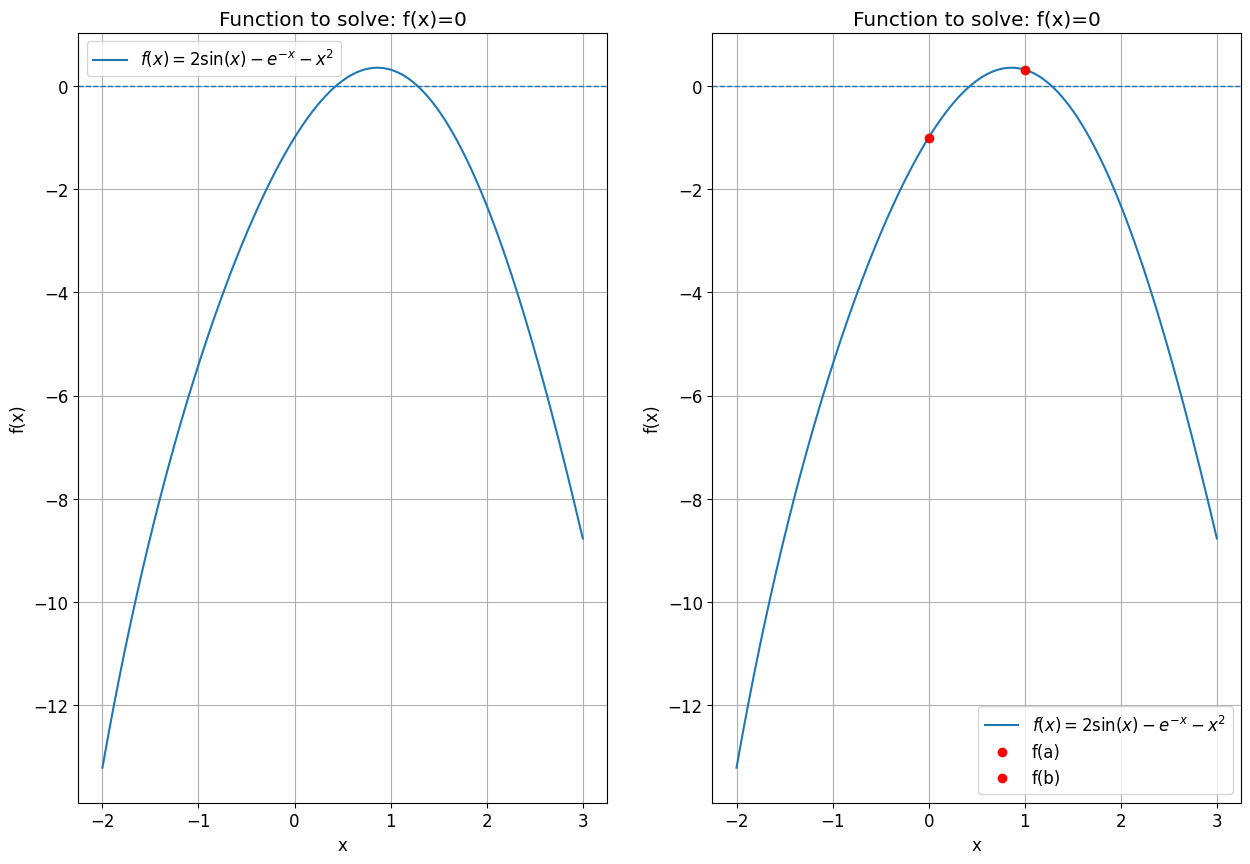

Suggested bracket: (0.0, 1.0)


In [3]:

xmin, xmax = problem["plot_interval"]
x = np.linspace(xmin, xmax, 500)
y = f(x)

plt.figure(figsize=(15, 10)) 
plt.subplot(1,2,1)
plt.plot(x, y, label=problem["description"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Function to solve: f(x)=0")
plt.grid(True)
plt.legend()


# TODO:
# Print f(a), f(b), and check whether the suggested bracket changes sign.
print("f(a) =",f(a))
print("f(b) =",f(b))


plt.subplot(1,2,2)
plt.plot(x, y, label=problem["description"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Function to solve: f(x)=0")
plt.grid(True)

plt.plot(a, f(a), "ro", label="f(a)")
plt.plot(b, f(b), "ro", label="f(b)")
plt.legend()
plt.show()

print("Suggested bracket:", (a, b))


## 3. Bisection method

**Objective.** Implement the bisection method.

The bisection method assumes that \(f\) is continuous and that the interval \([a,b]\) satisfies

$$
f(a)f(b)<0.
$$

At each iteration:

1. Compute the midpoint

$$
m=\frac{a+b}{2}.
$$

2. Decide whether the root lies in \([a,m]\) or \([m,b]\).
3. Repeat until the interval width or residual is small enough.

This method is robust, but it usually converges slowly compared with Newton's method.

In [4]:

def bisection(f, a, b, tol=DEFAULT_TOL, max_iter=DEFAULT_MAX_ITER):
    """
    Find a root of f in [a,b] using the bisection method.
    """
    history = []

    fa = f(a)
    fb = f(b)

    # TODO:
    # Check that the interval really brackets a root.
    # If not, raise a ValueError.

    if fa*fb > 0:
        raise ValueError("The interval [{}, {}] does not bracket a root.".format(a, b))
    else:
        print("The interval [{}, {}] brackets a root.".format(a, b))

    for n in range(max_iter):
        # TODO:
        # 1. Compute midpoint m.
        m = (a+b)/2
        # 2. Evaluate f(m).
        fm = f(m)
        # 3. Store iteration data in history.
        history.append((a, b, m, fm))
        #print(history[-1])
        # 4. Stop if |f(m)| < tol or interval width < tol.
        if abs(fm) < tol or (b - a) < tol:
            print("End of bisection: |f(m)| < tol or interval width < tol.\n")
            break
        # 5. Update either a or b.
        if fm * fa < 0:
            b = m
            fb = f(b)
        else:
            a = m
            fa = f(a)


        #raise NotImplementedError("Complete the bisection method.")

    return 0.5 * (a + b), history

### 3.1 Test the bisection method

**Objective.** Use your implementation to solve the lecture example.

Suggested checks:

- Does the returned value satisfy \(f(x)\approx 0\)?
- How many iterations were needed?
- How does the interval width decrease with iteration number?

The interval [0.0, 1.0] brackets a root.
End of bisection: |f(m)| < tol or interval width < tol.

Root = 0.4310378789668903
The returned value : -2.513025898487342e-11 satisfies f(x)~0.
Number of iterations needed: 33


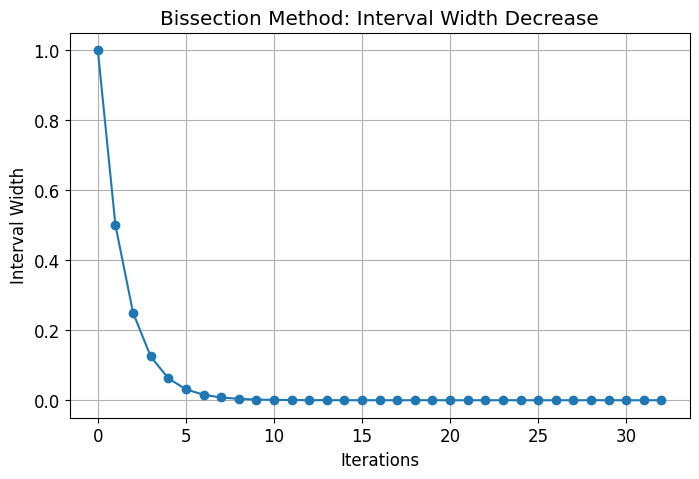

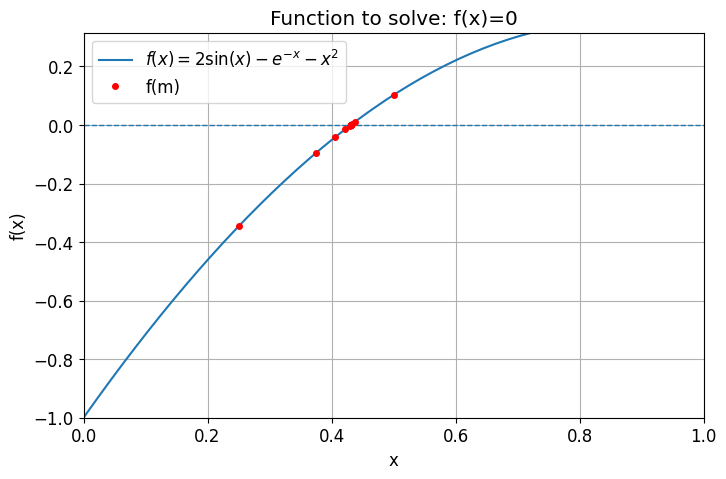

In [5]:

# TODO:
# Run the bisection method on the active problem.
root, history = bisection(f, a, b, DEFAULT_TOL, DEFAULT_MAX_ITER)
print("Root = {}".format(root))

# Does the returned value satisfy f(x)~0 ? 
if abs(f(root)) < DEFAULT_TOL:
    print("The returned value : {} satisfies f(x)~0.".format(f(root)))
else:
    print("The returned value : {} does not satisfy f(x)~0.".format(f(root)))

# Iterations needed 
print("Number of iterations needed: {}".format(len(history)))

# Interval width decrase

plt.figure()
plt.plot(np.arange(len(history)), [b-a for a,b,m,fm in history], marker='o')
plt.grid(True)
plt.xlabel("Iterations")
plt.ylabel("Interval Width")
plt.title("Bissection Method: Interval Width Decrease")

# Bissection evolution

plt.figure()
plt.plot(x, y, label=problem["description"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Function to solve: f(x)=0")
plt.grid(True)

plt.plot([m for a,b,m,fm in history] , [f(m) for a,b,m,fm in history], "ro",markersize=4, label="f(m)")
plt.xlim(a, b)
plt.ylim(f(a), f(b))
plt.legend()
plt.show()


## 4. Linear interpolation / false-position method

**Objective.** Implement a bracketing method that uses a straight-line approximation.

Given a bracketing interval \([a,b]\), instead of taking the midpoint, approximate the function by the line through \((a,f(a))\) and \((b,f(b))\). The zero of this line is

$$
c = \frac{a f(b)-b f(a)}{f(b)-f(a)}.
$$

This method is also called the **regula falsi** or **false-position method**.

In [6]:

def false_position(f, a, b, tol=DEFAULT_TOL, max_iter=DEFAULT_MAX_ITER):
    """
    Find a root of f in [a,b] using the false-position method.
    """
    history = []

    fa = f(a)
    fb = f(b)

    # TODO:
    # Check that [a,b] brackets a root.
    if fa*fb > 0:
            raise ValueError("The interval [{}, {}] does not bracket a root.".format(a, b))
    else:
            print("The interval [{}, {}] brackets a root.".format(a, b))


    for n in range(max_iter):
        # TODO:
        # Compute the linear interpolation estimate c.
        c = (a*fb - b*fa) / (fb - fa)
        # Evaluate f(c).
        fc = f(c)

        if abs(fc) < tol or (b - a) < tol:
                    print("End of false-position method: |f(c)| < tol or interval width < tol.\n")
                    break
        
        # Store iteration data.
        history.append((a, b, c, fc))
        # Update the bracket.
        if fc * fa < 0:
                b = c
                fb = fc
        else:
                a = c
                fa = fc
                

        #raise NotImplementedError("Complete the false-position method.")

    return c, history

### 4.1 Compare bisection and false position

**Objective.** Compare two bracketing methods.

Questions:

1. Which method uses fewer iterations for the lecture function? **False position method**
2. Does fewer iterations always mean the method is better? **Not really, it can also depend on the robustness of the method and the the calculation time behind each iteration**
3. Which method is more predictable? **Bisection because the speed of the false position method can vary depending on the shape of the function** 

The interval [0.0, 1.0] brackets a root.
End of false-position method: |f(c)| < tol or interval width < tol.

Root = 0.4310378790151874
Number of iterations needed: 20


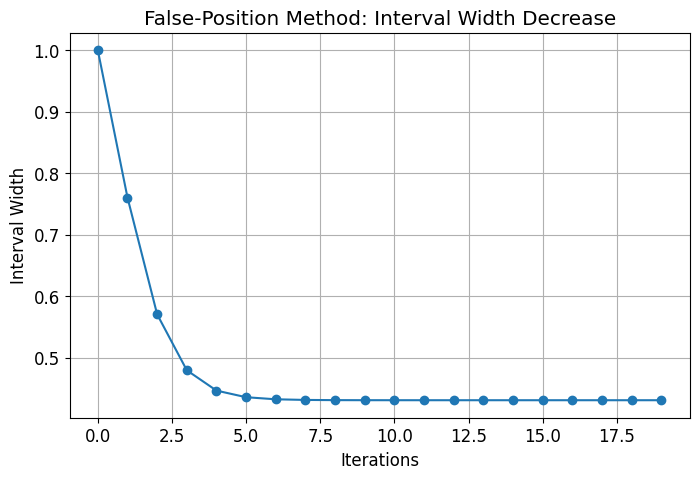

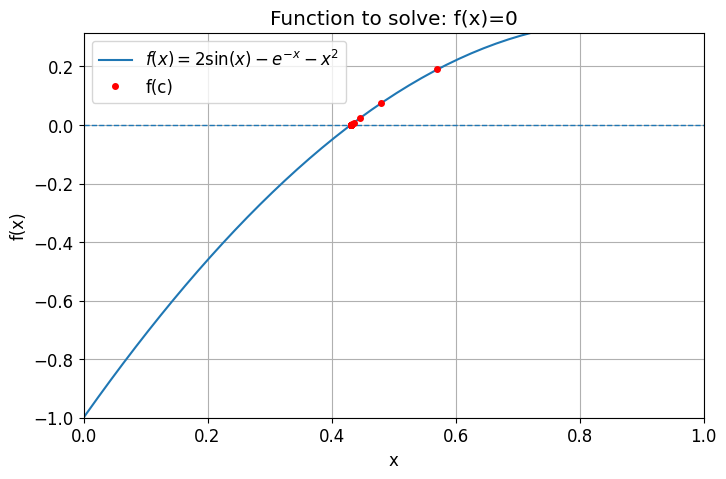

In [7]:

# TODO:
# Solve the same problem using false_position and compare with bisection.
root, history = false_position(f,a,b,DEFAULT_TOL,DEFAULT_MAX_ITER)
print("Root = {}".format(root))
# Iterations needed 
print("Number of iterations needed: {}".format(len(history)))

# Interval width decrase

plt.figure()
plt.plot(np.arange(len(history)), [b-a for a,b,m,fm in history], marker='o')
plt.grid(True)
plt.xlabel("Iterations")
plt.ylabel("Interval Width")
plt.title("False-Position Method: Interval Width Decrease")

# False-position evolution

plt.figure()
plt.plot(x, y, label=problem["description"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Function to solve: f(x)=0")
plt.grid(True)

plt.plot([c for a,b,c,fc in history] , [f(c) for a,b,c,fc in history], "ro",markersize=4, label="f(c)")
plt.xlim(a, b)
plt.ylim(f(a), f(b))
plt.legend()
plt.show()


## 5. Newton's method for one equation

**Objective.** Implement Newton's method.

Newton's method approximates the function by its tangent line at the current estimate \(x_n\). The next estimate is

$$
x_{n+1}=x_n-\frac{f(x_n)}{f'(x_n)}.
$$

Compared with bisection, Newton's method can be much faster. However, it requires a derivative and may fail if the starting point is poor or if \(f'(x_n)\) is close to zero.

In [8]:

def newton_scalar(f, df, x0, tol=DEFAULT_TOL, max_iter=DEFAULT_MAX_ITER):
    """
    Find a root of f using Newton's method.
    """
    history = []
    x = float(x0)

    for n in range(max_iter):
        # TODO:
        # Compute f(x), df(x), and the Newton update.
        fx = f(x)
        dfx = df(x)

        if dfx == 0:
            raise ValueError("f'(x) is zero at x = {}. Newton's method fails.".format(x))

        x2 = x - fx / dfx
        history.append((x2, fx, dfx))

        if abs(f(x2)) < tol or abs(x2 - x) < tol:
            #print("End of Newton's method: |f(c)| < tol or interval width < tol.")
            break

        x = x2

        #raise NotImplementedError("Complete Newton's method.")

    return x, history

### 5.1 Test Newton's method from several starting points

**Objective.** Explore sensitivity to the initial guess.

Try several starting values \(x_0\). Newton's method is not a bracketing method, so the result can depend strongly on the initial condition.

In [9]:

starting_points = [-1.0, 0.0, 0.5, 1.0, 2.0]

# TODO:
# Run Newton's method for each starting point and print the result.

for x0 in starting_points:
    root, history = newton_scalar(f, df, x0, DEFAULT_TOL, DEFAULT_MAX_ITER)
    print("Starting point {}: root = {}".format(x0, root))
    print("Iterations : {}\n".format(len(history)))


Starting point -1.0: root = 0.43103785126132327
Iterations : 6

Starting point 0.0: root = 0.4310378728898043
Iterations : 5

Starting point 0.5: root = 0.4310378771691554
Iterations : 4

Starting point 1.0: root = 1.279762546288077
Iterations : 6

Starting point 2.0: root = 1.2797667746783759
Iterations : 5



### 5.2 Plot Newton convergence

**Objective.** Visualize the decrease of the residual \(|f(x_n)|\).

For a well-behaved problem and a good initial guess, Newton's method often shows very rapid convergence.

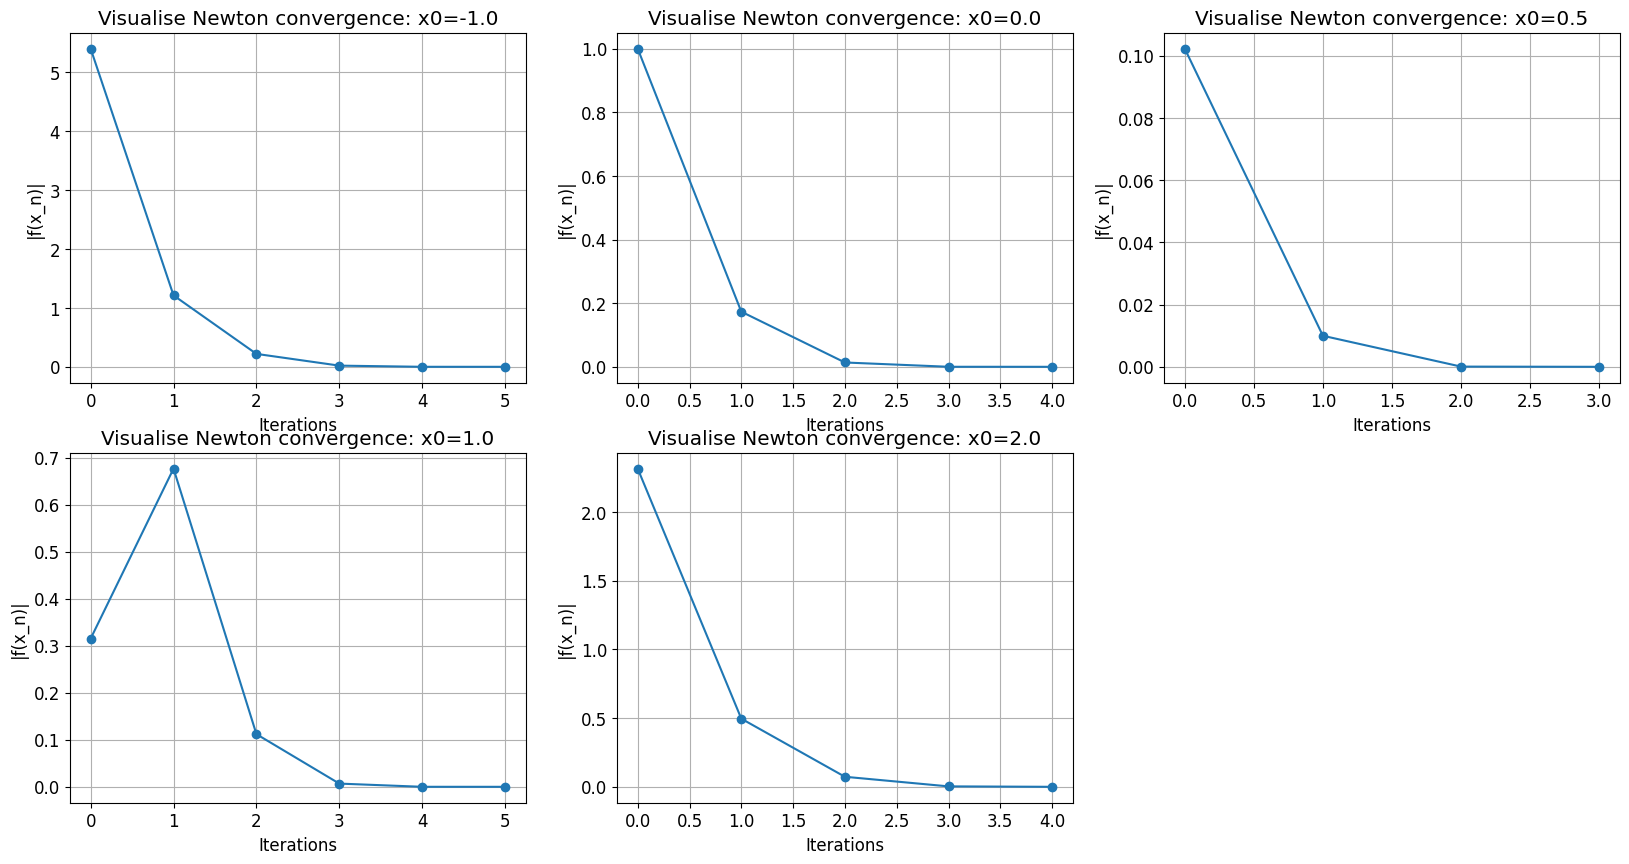

In [10]:

# TODO:
# Run Newton's method from the suggested starting point and plot |f(x_n)|.
plt.figure(figsize=(20, 10))

for x0 in starting_points:
    root, history = newton_scalar(f, df, x0, DEFAULT_TOL, DEFAULT_MAX_ITER)
    plt.subplot(2,3,starting_points.index(x0)+1)
    plt.plot(np.arange(len(history)), [abs(fx) for x, fx, dfx in history], marker='o', label="x0={}".format(x0))
    plt.grid(True)
    plt.xlabel("Iterations")
    plt.ylabel("|f(x_n)|")
    plt.title("Visualise Newton convergence: x0={}".format(x0))

## 6. Fixed-point iteration

**Objective.** Solve \(f(x)=0\) by rewriting the problem as

$$
x=g(x)
$$

and then iterating

$$
x_{n+1}=g(x_n).
$$

This method is simple, but convergence depends strongly on the choice of \(g\). A useful local criterion is:

$$
|g'(x_\ast)|<1
$$

near the fixed point \(x_\ast\).

In [30]:

# Example fixed-point maps for the lecture equation.
#
# The original equation is:
#     2 sin(x) - exp(-x) - x^2 = 0
#
# One possible rearrangement is:
#     x = sqrt(2 sin(x) - exp(-x))
#
# This map is only valid where the expression under the square root is positive.

def g1_lecture(x):
    return np.sqrt(2*np.sin(x) - np.exp(-x))

# Another artificial fixed-point map can be built from:
#     x_{n+1} = x_n - alpha f(x_n)
# This is not Newton's method unless alpha = 1 / f'(x_n).
def make_relaxation_map(f, alpha):
    def g(x):
        return x - alpha * f(x)
    return g

g2_lecture = make_relaxation_map(f_lecture, alpha=0.2)

In [45]:

def fixed_point_iteration(g, x0, tol=DEFAULT_TOL, max_iter=DEFAULT_MAX_ITER):
    """
    Fixed-point iteration x_{n+1} = g(x_n).
    """
    history = []
    x = float(x0)

    for n in range(max_iter):
        # TODO:
        # Compute x_new = g(x), store data, and check convergence.
        x_new = g(x)
        history.append(x_new)
        #print("x{} = {}".format(n + 1, x_new))

        # converge ?
        if n >= 2:
            if abs(history[-1]-history[-2])>abs(history[-2]-history[-3]):
                print("Fixed-point iteration is diverging :(")
                x = "undefined"
                break

        if abs(x_new - x) < tol:
            print("End of fixed-point iteration: |x_new - x| < tol.\n")
            x = x_new
            break

        x = x_new
        #raise NotImplementedError("Complete fixed-point iteration.")

    return x, history

### 6.1 Try different fixed-point maps

**Objective.** Show that fixed-point iteration can converge or diverge depending on how the problem is rearranged.

Tasks:

1. Try `g1_lecture`.
2. Try `g2_lecture`.
3. Change `alpha` in the relaxation map and observe what happens.

In [58]:

# TODO:
# Try fixed-point iteration with different maps.
root1, history1 = fixed_point_iteration(g1_lecture, x0, DEFAULT_TOL, DEFAULT_MAX_ITER)
print("Root = {}: Iteration : {}\n".format(root1, len(history1)))
root2, history2 = fixed_point_iteration(g2_lecture, x0, DEFAULT_TOL, DEFAULT_MAX_ITER)
print("Root = {}: Iteration : {}\n".format(root2, len(history2)))

print("\n\n")

for i in [-0.5,-0.4,-0.3,-0.2,-0.1, 0.1, 0.2, 0.3, 0.4, 0.5]:
    print("Relaxation parameter alpha = {}".format(i))
    g2_lecture = make_relaxation_map(f_lecture, i)
    root, history = fixed_point_iteration(g2_lecture, x0, DEFAULT_TOL, DEFAULT_MAX_ITER)
    print("Root = {}: Iteration : {}\n".format(root, len(history)))
    

End of fixed-point iteration: |x_new - x| < tol.

Root = 1.2797625458729234: Iteration : 19

Fixed-point iteration is diverging :(
Root = undefined: Iteration : 3




Relaxation parameter alpha = -0.5
End of fixed-point iteration: |x_new - x| < tol.

Root = 1.2797625458267003: Iteration : 16

Relaxation parameter alpha = -0.4
End of fixed-point iteration: |x_new - x| < tol.

Root = 1.2797625458144477: Iteration : 22

Relaxation parameter alpha = -0.3
End of fixed-point iteration: |x_new - x| < tol.

Root = 1.2797625459203832: Iteration : 28

Relaxation parameter alpha = -0.2
End of fixed-point iteration: |x_new - x| < tol.

Root = 1.2797625459722366: Iteration : 51

Relaxation parameter alpha = -0.1
Root = 1.2797625482871533: Iteration : 100

Relaxation parameter alpha = 0.1
Fixed-point iteration is diverging :(
Root = undefined: Iteration : 3

Relaxation parameter alpha = 0.2
Fixed-point iteration is diverging :(
Root = undefined: Iteration : 3

Relaxation parameter alpha = 0.3
Fixed-

## 7. Newton's method for a system of nonlinear equations

**Objective.** Solve a system

$$
F(\mathbf{x})=\mathbf{0}
$$

using Newton's method.

The lecture example is

$$
F_1(x,y)=e^x-3y-1=0,
$$

$$
F_2(x,y)=x^2+y^2-4=0.
$$
Newton's method for systems uses the Jacobian matrix

$$
J(\mathbf{x}_n)\Delta \mathbf{x}_n=-F(\mathbf{x}_n),
$$

then updates

$$
\mathbf{x}_{n+1}=\mathbf{x}_n+\Delta \mathbf{x}_n.
$$

In [63]:

# ============================================================
# System root-finding problem: F(x, y) = 0
# ============================================================

def F_system(v):
    """
    Lecture system:
        F1(x,y) = exp(x) - 3y - 1
        F2(x,y) = x^2 + y^2 - 4
    """
    x, y = v
    return np.array([
        np.exp(x) - 3*y - 1,
        x**2 + y**2 - 4
    ], dtype=float)

def J_system(v):
    """
    Jacobian of F_system.
    """
    x, y = v
    return np.array([
        [np.exp(x), -3],
        [2*x,       2*y]
    ], dtype=float)


def newton_system(F, J, v0, tol=DEFAULT_TOL, max_iter=DEFAULT_MAX_ITER):
    """
    Newton's method for a nonlinear system F(v)=0.
    """
    history = []
    v = np.array(v0, dtype=float)

    for n in range(max_iter):
        # TODO:
        # 1. Evaluate F(v) and J(v).
        Fv =  F(v)
        Jv = J(v)
        # 2. Solve J(v) delta = -F(v).
        delta = np.linalg.solve(Jv, -Fv)
        # 3. Update v_new = v + delta.
        v_new = v + delta
        # 4. Store convergence data.
        history.append((v_new, Fv, Jv, delta))
        # 5. Stop if norm(F(v)) or norm(delta) is small.
        if np.linalg.norm(Fv) < tol or np.linalg.norm(delta) < tol:
            print("End of Newton's method for systems: norm(F(v)) < tol or norm(delta) < tol.\n")
            v = v_new
            break

        v = v_new
        #raise NotImplementedError("Complete Newton's method for systems.")

    return v, history

### 7.1 Visualize the nonlinear system

**Objective.** Plot the two curves

$$
e^x-3y-1=0
$$

and

$$
x^2+y^2-4=0.
$$

Solutions of the system are intersection points.

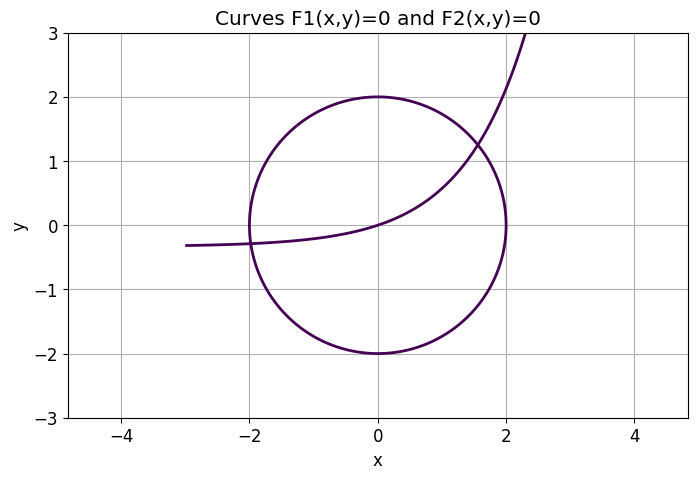

In [60]:

x_grid = np.linspace(-3, 3, 400)
y_grid = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x_grid, y_grid)

Z1 = np.exp(X) - 3*Y - 1
Z2 = X**2 + Y**2 - 4

plt.contour(X, Y, Z1, levels=[0], linewidths=2)
plt.contour(X, Y, Z2, levels=[0], linewidths=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Curves F1(x,y)=0 and F2(x,y)=0")
plt.axis("equal")
plt.grid(True)
plt.show()

### 7.2 Solve the nonlinear system from several initial guesses

**Objective.** Show that Newton's method for systems can converge to different roots depending on the starting point.

In [65]:

initial_guesses = [
    [-2.0, 1.0],
    [0.0, 1.0],
    [1.0, 1.0],
    [2.0, 1.0],
    [1.0, -1.0],
]

# TODO:
# Run newton_system for each initial guess.
for initial_guess in initial_guesses:
   
    root, history = newton_system(F_system, J_system, initial_guess, DEFAULT_TOL, DEFAULT_MAX_ITER)
    print ("Initial guess {}: root = {}".format(initial_guess, root))



End of Newton's method for systems: norm(F(v)) < tol or norm(delta) < tol.

Initial guess [-2.0, 1.0]: root = [-1.97926056 -0.28727621]
End of Newton's method for systems: norm(F(v)) < tol or norm(delta) < tol.

Initial guess [0.0, 1.0]: root = [1.55951219 1.25216681]
End of Newton's method for systems: norm(F(v)) < tol or norm(delta) < tol.

Initial guess [1.0, 1.0]: root = [1.55951219 1.25216681]
End of Newton's method for systems: norm(F(v)) < tol or norm(delta) < tol.

Initial guess [2.0, 1.0]: root = [1.55951219 1.25216681]
End of Newton's method for systems: norm(F(v)) < tol or norm(delta) < tol.

Initial guess [1.0, -1.0]: root = [1.55951219 1.25216681]


# Extension 1 — Multiple roots and modified Newton's method

A multiple root can make standard Newton's method converge more slowly.

Consider

$$
f(x)=x^4-4x^2+4=(x^2-2)^2.
$$

The roots \(x=\pm\sqrt{2}\) have multiplicity 2.

For a root of known multiplicity \(m\), a modified Newton iteration is

$$
x_{n+1}=x_n - m\frac{f(x_n)}{f'(x_n)}.
$$

Another version, not requiring explicit knowledge of multiplicity, is

$$
x_{n+1}=x_n-\frac{f(x_n)f'(x_n)}{(f'(x_n))^2-f(x_n)f''(x_n)}.
$$

## 8. Compare standard and modified Newton for a multiple root

**Objective.** Observe that standard Newton can lose its usual fast convergence near a multiple root.

Tasks:

1. Solve $x^4-4x^2+4=0$ using standard Newton.
2. Implement the known-multiplicity modified Newton method with \(m=2\).
3. Implement the derivative-based modified Newton method.
4. Compare convergence histories.

In [17]:

def modified_newton_known_multiplicity(f, df, x0, multiplicity, tol=DEFAULT_TOL, max_iter=DEFAULT_MAX_ITER):
    """
    Modified Newton method when root multiplicity m is known:
        x_{n+1} = x_n - m f(x_n)/f'(x_n)
    """
    history = []
    x = float(x0)
    m = multiplicity

    for n in range(max_iter):
        # TODO:
        # Implement the modified Newton update.

        raise NotImplementedError("Complete modified Newton with known multiplicity.")

    return x, history


def modified_newton_using_second_derivative(f, df, ddf, x0, tol=DEFAULT_TOL, max_iter=DEFAULT_MAX_ITER):
    """
    Modified Newton method:
        x_{n+1} = x_n - f f' / ((f')^2 - f f'')
    """
    history = []
    x = float(x0)

    for n in range(max_iter):
        # TODO:
        # Implement the derivative-based modified Newton update.

        raise NotImplementedError("Complete modified Newton using second derivative.")

    return x, history

In [18]:

# Select multiple-root problem.
multi = scalar_problems["multiple_root"]
fm = multi["f"]
dfm = multi["df"]
ddfm = multi["ddf"]
x0_multi = multi["x0"]

# TODO:
# Compare standard Newton, modified Newton with known multiplicity,
# and modified Newton using second derivative.

# Extension 2 — Newton fractal for \(z^3-1=0\)

Newton's method can be applied to complex numbers.

For

\[
p(z)=z^3-1,
\]

the three roots are

\[
1,\qquad -\frac{1}{2}+\frac{\sqrt{3}}{2}i,\qquad -\frac{1}{2}-\frac{\sqrt{3}}{2}i.
\]

Newton's method becomes

\[
z_{n+1}=z_n-\frac{p(z_n)}{p'(z_n)}
      =z_n-\frac{z_n^3-1}{3z_n^2}.
\]

Starting from each point \(z_0\) in the complex plane, the iteration may converge to one of the three roots. Coloring each starting point by the root reached gives a **Newton fractal**.

## 9. Define the complex polynomial and Newton step

**Objective.** Define \(p(z)\), \(p'(z)\), and one Newton update in the complex plane.

You can experiment by replacing `p_complex` and `dp_complex` with another polynomial and its derivative.

In [19]:

# ============================================================
# Complex root-finding problem for Newton fractal
# ============================================================

def p_complex(z):
    """Polynomial p(z)=z^3-1."""
    return z**3 - 1

def dp_complex(z):
    """Derivative p'(z)=3z^2."""
    return 3*z**2

complex_roots = np.array([
    1 + 0j,
    -0.5 + 0.5*np.sqrt(3)*1j,
    -0.5 - 0.5*np.sqrt(3)*1j,
])

def newton_step_complex(z):
    """
    One Newton update for the complex polynomial.
    """
    # TODO:
    # Return z - p(z)/p'(z).

    # Uncomment / complete:
    # return z - p_complex(z) / dp_complex(z)

    raise NotImplementedError("Complete the complex Newton step.")

## 10. Iterate Newton's method on a grid of complex starting points

**Objective.** Apply Newton's method to many initial guesses in the complex plane.

Tasks:

1. Create a grid of complex numbers \(z=x+iy\).
2. Apply Newton's method repeatedly.
3. For each initial point, determine which root it converges to.

In [20]:

def compute_newton_fractal(xmin=-2, xmax=2, ymin=-2, ymax=2, N=400, max_iter=30, tol=1e-8):
    """
    Compute Newton fractal data for p(z)=z^3-1.
    """
    x = np.linspace(xmin, xmax, N)
    y = np.linspace(ymin, ymax, N)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j*Y

    root_index = -np.ones(Z.shape, dtype=int)
    iterations = np.zeros(Z.shape, dtype=int)

    active = np.ones(Z.shape, dtype=bool)

    for n in range(max_iter):
        # TODO:
        # 1. Update only active points.
        # 2. Check distance to the known roots.
        # 3. Assign root index when convergence is reached.
        # 4. Mark those points as no longer active.

        raise NotImplementedError("Complete the Newton fractal iteration.")

    return root_index, iterations

## 11. Plot the Newton fractal

**Objective.** Visualize the basins of attraction of the three roots.

Each color corresponds to a root of \(z^3-1=0\). Boundaries between colors show strong sensitivity to the starting point.

In [21]:

# TODO:
# Compute and plot the Newton fractal.


## 12. Reflection questions

**Objective.** Consolidate the numerical observations.

Answer these questions in a few sentences.

1. Why is bisection robust?
2. Why can Newton's method be faster than bisection?
3. What can go wrong with Newton's method?
4. Why does a multiple root slow down standard Newton's method?
5. In the Newton fractal, why do nearby initial guesses sometimes converge to different roots?
6. For an engineering or physics simulation, when would you prefer a slower but more robust method?

In [22]:

# Write your answers here as comments or markdown.

# 1.
#
# 2.
#
# 3.
#
# 4.
#
# 5.
#
# 6.